# Sign Language Detection using CNN

**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Assessment:** Final Portfolio - Part II Vision Task  
**Student_Name:** Adarsha Ghimire

**Notebook:** Image Classification using CNN, Deeper CNN, Optimizer Comparison, Ablation Study, and Transfer Learning

## Project Aim

This notebook builds an end-to-end image classification system for sign language gesture detection.

The notebook includes:

1. Google Drive dataset loading and extraction  
2. Automatic Train/Test folder detection  
3. Corrupted/non-image file cleaning  
4. Dataset statistics and class distribution  
5. Image visualization and augmentation  
6. Baseline CNN from scratch  
7. Deeper CNN with Batch Normalization and Dropout  
8. Optimizer comparison: Adam vs SGD  
9. Ablation study: deeper CNN without Dropout  
10. Transfer learning using MobileNetV2  
11. Optional fine-tuning  
12. Evaluation using accuracy, precision, recall, F1-score, classification report, and confusion matrix  
13. Final comparison table and viva notes  


## 1. Import Required Libraries

In [114]:
# Import important libraries
import os
import time
import shutil
import zipfile
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.metrics import (

    precision_score,

    recall_score,

    f1_score,

    classification_report,

    confusion_matrix
)
# For building deep learning models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
# For loading image data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# For model evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Set random seed (helps get same result every time)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Check TensorFlow version
print("TensorFlow Version:", tf.__version__)

# Check if GPU is available
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Mount Google Drive, Copy ZIP to Colab, and Extract Dataset

This is the efficient method: keep the ZIP in Google Drive, copy it to `/content`, extract inside `/content`, and train from `/content`.

Expected Drive file path:

In [63]:


from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# ZIP file path
zip_path = "/content/drive/MyDrive/SignLanguageDetection.zip"

# Extraction folder
extract_path = "/content/dataset"

# Extract ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

# Dataset paths
train_dir = "/content/dataset/Train"
test_dir = "/content/dataset/Test"

# Show dataset folders
print(os.listdir(extract_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Extracted Successfully!
['Sign Language Detection']


## 3. Automatically Detect Train and Test Directories

This cell finds folders like `Train`, `train`, `Test`, or `test`.  
If the test folder has no images, the notebook will use the validation set for evaluation.


In [64]:
# Image formats
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# Function to count images
def count_images(folder_path):

    total_images = 0

    for root, dirs, files in os.walk(folder_path):

        for file in files:

            if file.lower().endswith(tuple(image_extensions)):
                total_images += 1

    return total_images


# Function to find folder
def find_folder(base_path, folder_names):

    for root, dirs, files in os.walk(base_path):

        for folder in dirs:

            if folder.lower() in folder_names:

                full_path = os.path.join(root, folder)

                image_count = count_images(full_path)

                return full_path, image_count

    return None, 0


# Find train folder
TRAIN_DIR, train_count = find_folder(
    extract_path,
    ["train", "training"]
)

# Find test folder
TEST_DIR, test_count = find_folder(
    extract_path,
    ["test", "testing", "validation"]
)


# Show results
print("Train Folder :", TRAIN_DIR)
print("Train Images :", train_count)

print("\nTest Folder :", TEST_DIR)
print("Test Images :", test_count)


# Error if train folder missing
if TRAIN_DIR is None:
    raise FileNotFoundError("Train folder not found!")


# Warning if test folder missing
if TEST_DIR is None or test_count == 0:

    print("\nNo test images found.")
    print("Validation data will be used for evaluation.")

Train Folder : /content/dataset/Sign Language Detection/Train
Train Images : 11058

Test Folder : /content/dataset/Sign Language Detection/Test
Test Images : 3


## 4. Clean Corrupted or Non-Image Files

This fixes `UnidentifiedImageError: cannot identify image file`.  
It removes hidden files, non-image files, and corrupted images before Keras creates generators.


In [65]:
# Valid image formats
valid_formats = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Function to remove bad images
def clean_images(folder_path):

    removed = 0

    for root, dirs, files in os.walk(folder_path):

        for file in files:

            file_path = os.path.join(root, file)

            # Skip non-image files
            if not file.lower().endswith(valid_formats):

                os.remove(file_path)
                removed += 1
                continue

            # Check corrupted images
            try:
                img = Image.open(file_path)
                img.verify()

            except:
                os.remove(file_path)
                removed += 1

    return removed


# Clean train folder
train_removed = clean_images(TRAIN_DIR)

# Clean test folder
test_removed = clean_images(TEST_DIR)


# Show results
print("Removed from Train Folder:", train_removed)

print("Removed from Test Folder :", test_removed)

print("\nDataset Cleaning Complete!")

Removed from Train Folder: 266
Removed from Test Folder : 0

Dataset Cleaning Complete!


## 5. Dataset Statistics and Class Distribution



Total Classes : 38
Total Images : 10792


,Class,Images
0,14,270
1,4,239
2,10,291
3,26,285
4,25,287


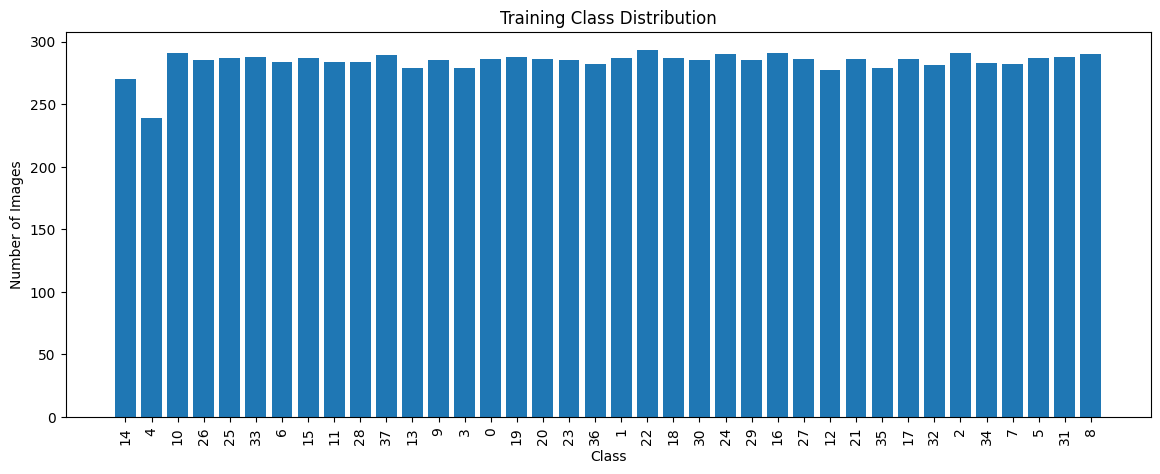

count     38.000000
mean     284.000000
std        8.708492
min      239.000000
25%      283.250000
50%      286.000000
75%      287.750000
max      293.000000
Name: Images, dtype: float64


In [66]:

# Store class names and image counts
classes = []
image_counts = []

# Read all class folders
for folder in os.listdir(TRAIN_DIR):

    folder_path = os.path.join(TRAIN_DIR, folder)

    if os.path.isdir(folder_path):

        count = len(os.listdir(folder_path))

        classes.append(folder)

        image_counts.append(count)


# Create dataframe
train_df = pd.DataFrame({
    "Class": classes,
    "Images": image_counts
})


# Show dataset information
print("Total Classes :", len(train_df))

print("Total Images :", train_df["Images"].sum())

display(train_df.head())


# Plot graph
plt.figure(figsize=(14,5))

plt.bar(train_df["Class"], train_df["Images"])

plt.title("Training Class Distribution")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.xticks(rotation=90)

plt.show()


# Statistical summary
print(train_df["Images"].describe())

## 6. Show sample images from dataset


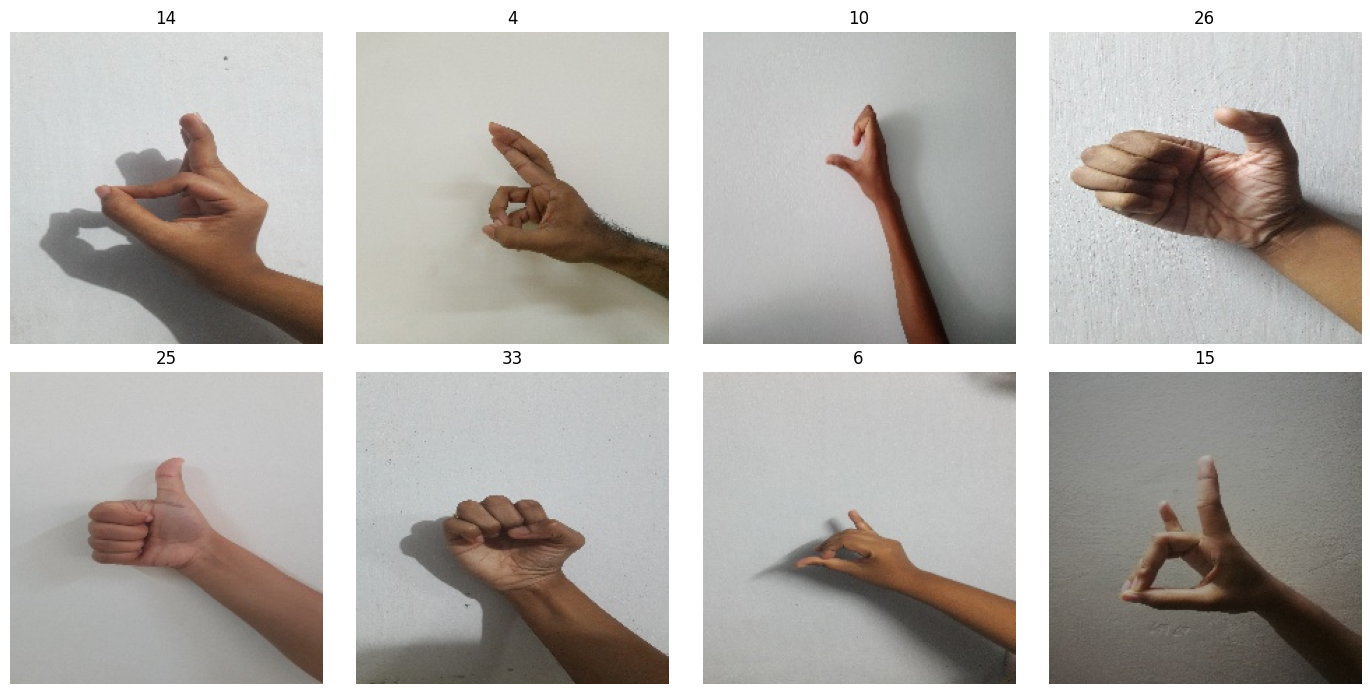

In [67]:

classes = os.listdir(TRAIN_DIR)[:8]

plt.figure(figsize=(14,7))

for i, class_name in enumerate(classes):

    class_path = os.path.join(TRAIN_DIR, class_name)

    images = os.listdir(class_path)

    random_image = random.choice(images)

    image_path = os.path.join(class_path, random_image)

    img = Image.open(image_path)

    plt.subplot(2,4,i+1)

    plt.imshow(img)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()

plt.show()

# 7.Model settings


In [68]:

IMAGE_SIZE = 128

BATCH = 32

BASELINE_EPOCHS = 25

DEEP_MODEL_EPOCHS = 30

TRANSFER_EPOCHS = 15

FINE_TUNE_EPOCHS = 10


# Display settings
print("Image Size :", IMAGE_SIZE)

print("Batch Size :", BATCH)

print("Baseline Training Epochs :", BASELINE_EPOCHS)

print("Deep CNN Epochs :", DEEP_MODEL_EPOCHS)

print("Transfer Learning Epochs :", TRANSFER_EPOCHS)

print("Fine Tuning Epochs :", FINE_TUNE_EPOCHS)

Image Size : 128
Batch Size : 32
Baseline Training Epochs : 25
Deep CNN Epochs : 30
Transfer Learning Epochs : 15
Fine Tuning Epochs : 10


#8.Create Data Generators

This section prepares the dataset for model training.

Training data uses augmentation such as rotation, zooming, and shifting to improve model accuracy.
Validation and test data are only rescaled.

If no valid test folder is available, the notebook uses the validation set for final evaluation.

In [69]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.15,

    rotation_range=15,

    zoom_range=0.15,

    width_shift_range=0.1,

    height_shift_range=0.1
)


# Validation data
val_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.15
)


# Test data
test_datagen = ImageDataGenerator(

    rescale=1./255
)


# Training generator
train_generator = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=(128,128),

    batch_size=BATCH,

    class_mode="categorical",

    subset="training",

    shuffle=True
)


# Validation generator
val_generator = val_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=(128,128),

    batch_size=BATCH,

    class_mode="categorical",

    subset="validation",

    shuffle=False
)


# Test generator
test_generator = test_datagen.flow_from_directory(

    TEST_DIR,

    target_size=(128,128),

    batch_size=BATCH,

    class_mode="categorical",

    shuffle=False
)


# Dataset information
NUM_CLASSES = train_generator.num_classes

print("Total Classes :", NUM_CLASSES)

print("Class Names :")

print(train_generator.class_indices)

Found 9194 images belonging to 38 classes.
Found 1598 images belonging to 38 classes.
Found 0 images belonging to 0 classes.
Total Classes : 38
Class Names :
{'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '4': 32, '5': 33, '6': 34, '7': 35, '8': 36, '9': 37}


## 9. Display Sample Training Images

This section displays sample augmented images from the training dataset.



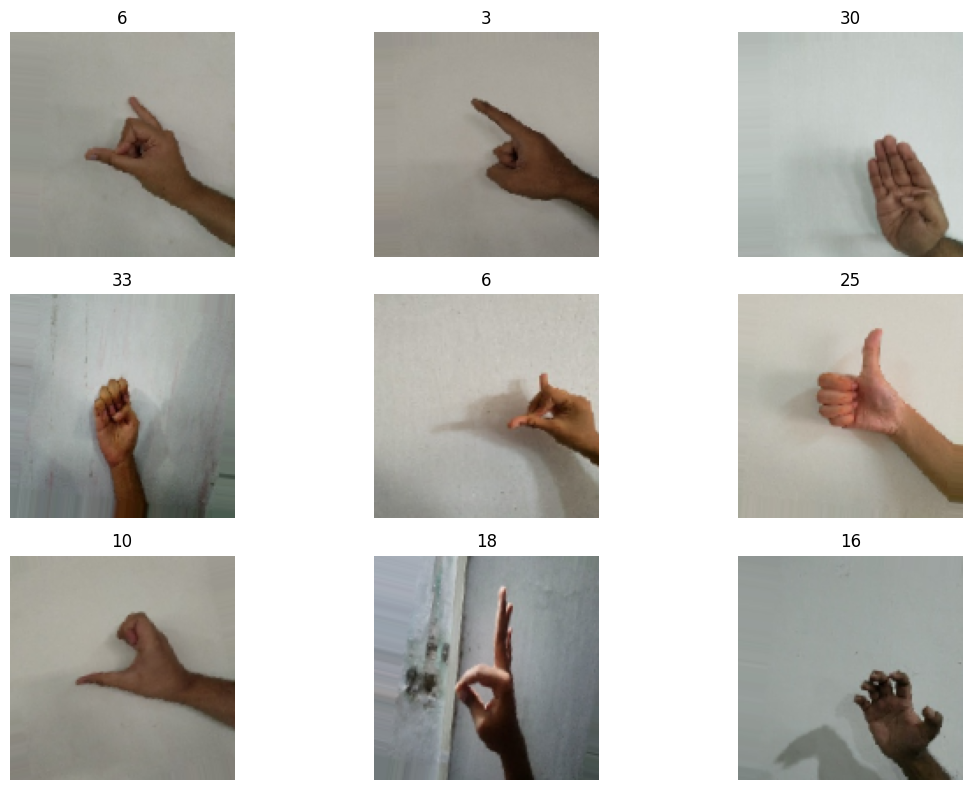

In [70]:
# Get training images
images, labels = next(train_generator)

# Create a mapping from index to class name
class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

# Display images
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(idx_to_class[np.argmax(labels[i])])

    plt.axis("off")

plt.tight_layout()

plt.show()

#10. Training Utilities and Model Evaluation

This section creates helper functions for training and evaluating deep learning models.

In [96]:
# Training callbacks
def get_callbacks():

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3
    )

    return [early_stop, reduce_lr]


# Plot training graphs
def plot_graphs(history, model_name):

    # Accuracy graph
    plt.figure(figsize=(8,5))

    plt.plot(history.history["accuracy"])

    plt.plot(history.history["val_accuracy"])

    plt.title(model_name + " Accuracy")

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.legend(["Train", "Validation"])

    plt.show()


    # Loss graph
    plt.figure(figsize=(8,5))

    plt.plot(history.history["loss"])

    plt.plot(history.history["val_loss"])

    plt.title(model_name + " Loss")

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.legend(["Train", "Validation"])

    plt.show()


# Evaluate model
def evaluate_model(model, generator, model_name):

    predictions = model.predict(generator)

    predicted_labels = np.argmax(predictions, axis=1)

    true_labels = generator.classes


    # Accuracy
    accuracy = np.mean(predicted_labels == true_labels)


    # Classification report (to get f1-score)
    report = classification_report(
        true_labels,
        predicted_labels,
        output_dict=True,
        zero_division=0 # Handle cases with no predicted samples for a class
    )
    f1_score_metric = report['weighted avg']['f1-score'] # Extract weighted average F1-score


    print("\n", model_name)

    print("Accuracy :", accuracy)


    print("\nClassification Report:\n")

    print(classification_report(
        true_labels,
        predicted_labels,
        zero_division=0
    ))


    # Confusion matrix
    cm = confusion_matrix(
        true_labels,
        predicted_labels
    )

    plt.figure(figsize=(10,8))

    plt.imshow(cm)

    plt.title(model_name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.colorbar()

    plt.show()

    # Return results as a dictionary
    return {
        "model": model_name,
        "accuracy": accuracy,
        "f1_score": f1_score_metric
    }

# Part A: CNN Models from Scratch

#11.Build Baseline CNN Model

This section creates the first Convolutional Neural Network (CNN) model for sign language classification.


In [72]:

# Build baseline CNN model

def create_baseline_model(num_classes):

    model = Sequential([

        Conv2D(32, (3,3),
               activation="relu",
               input_shape=(128,128,3)),

        MaxPooling2D(2,2),


        Conv2D(64, (3,3),
               activation="relu"),

        MaxPooling2D(2,2),


        Conv2D(128, (3,3),
               activation="relu"),

        MaxPooling2D(2,2),


        Flatten(),


        Dense(256, activation="relu"),

        Dropout(0.5),


        Dense(128, activation="relu"),

        Dropout(0.3),


        Dense(num_classes,
              activation="softmax")
    ])


    # Compile model
    model.compile(

        optimizer=Adam(0.001),

        loss="categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model


# Create model
baseline_model = create_baseline_model(NUM_CLASSES)


# Show model structure
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,553,830 (25.00 MB)

 Trainable params: 6,553,830 (25.00 MB)

 Non-trainable params: 0 (0.00 B)

# 12.Train baseline CNN
This section trains the baseline CNN model using the training dataset.

In [97]:
print("Training Baseline CNN...")

start_time = time.time()
history_baseline = baseline_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=BASELINE_EPOCHS,

    callbacks=get_callbacks()
)
end_time = time.time()
baseline_time = end_time - start_time

Training Baseline CNN...
Epoch 1/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 168ms/step - accuracy: 0.7001 - loss: 0.9386 - val_accuracy: 0.6952 - val_loss: 1.1690 - learning_rate: 9.0000e-05
Epoch 2/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 173ms/step - accuracy: 0.6996 - loss: 0.9330 - val_accuracy: 0.6965 - val_loss: 1.2178 - learning_rate: 9.0000e-05
Epoch 3/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 47s 164ms/step - accuracy: 0.7051 - loss: 0.9108 - val_accuracy: 0.6946 - val_loss: 1.2288 - learning_rate: 9.0000e-05
Epoch 4/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 166ms/step - accuracy: 0.7058 - loss: 0.9120 - val_accuracy: 0.6846 - val_loss: 1.2708 - learning_rate: 9.0000e-05
Epoch 5/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 49s 169ms/step - accuracy: 0.7083 - loss: 0.9165 - val_accuracy: 0.7028 - val_loss: 1.2334 - learning_rate: 2.7000e-05
Epoch 6/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 46s 161ms/step - accuracy: 0.7069 - loss: 0.9085 - val_accuracy: 0.6959 - val_loss: 1.2242 - learning_rate: 2.7000e-05


#13. Evaluate Baseline CNN

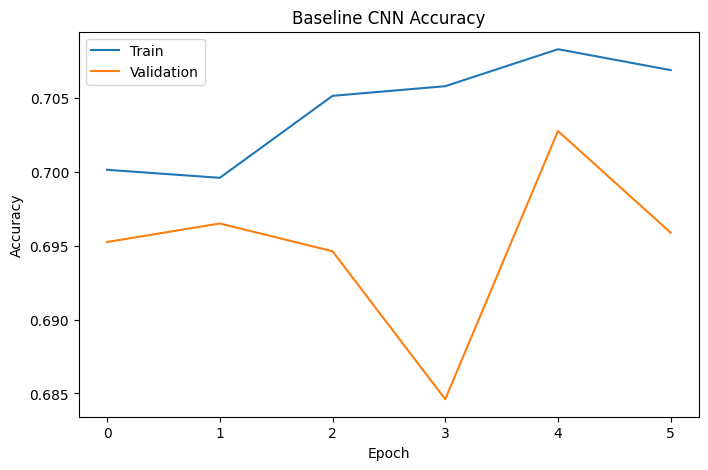

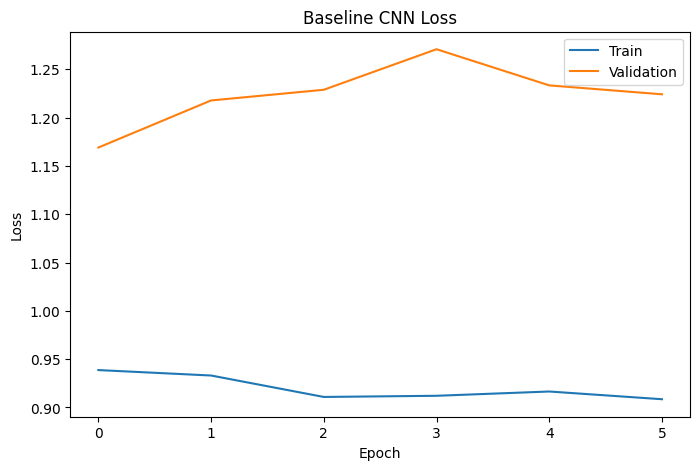

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step

 Baseline CNN
Accuracy : 0.695244055068836

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.71      0.67        42
           1       0.68      0.79      0.73        43
           2       0.86      0.70      0.77        43
           3       0.76      0.76      0.76        42
           4       0.66      0.66      0.66        41
           5       0.65      0.59      0.62        41
           6       0.79      0.55      0.65        40
           7       0.78      0.58      0.67        43
           8       0.74      0.79      0.76        43
           9       0.94      0.76      0.84        42
          10       0.61      0.77      0.68        43
          11       0.56      0.23      0.33        43
          12       0.60      0.79      0.68        43
          13       0.70      0.76      0.73        42
          14       0.80      0.83      0.81        42
          15       0.54   

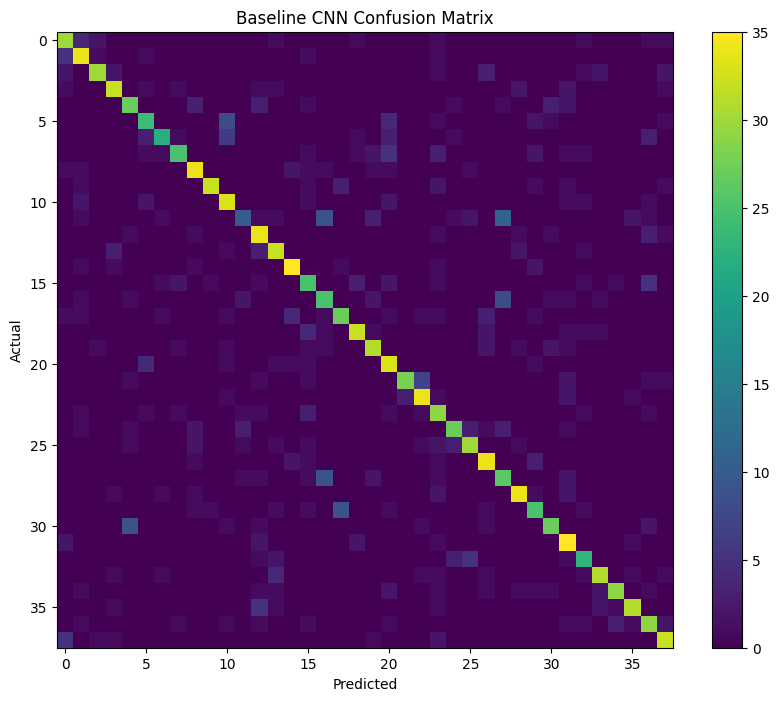

In [99]:
import time
from sklearn.metrics import classification_report, confusion_matrix

# Accuracy and loss graphs
plot_graphs(history_baseline, "Baseline CNN")

# Model evaluation
baseline_results = evaluate_model(
    baseline_model,
    val_generator,
    "Baseline CNN"
)

#14. Build Deeper CNN Model

In [75]:
def create_deep_model(num_classes):

    model = Sequential([

        Conv2D(32, (3,3),
               activation="relu",
               padding="same",
               input_shape=(128,128,3)),

        BatchNormalization(),

        MaxPooling2D(2,2),

        Dropout(0.25),


        Conv2D(64, (3,3),
               activation="relu",
               padding="same"),

        BatchNormalization(),

        MaxPooling2D(2,2),

        Dropout(0.30),


        Conv2D(128, (3,3),
               activation="relu",
               padding="same"),

        BatchNormalization(),

        MaxPooling2D(2,2),

        Dropout(0.40),


        Flatten(),


        Dense(256, activation="relu"),

        Dropout(0.50),


        Dense(num_classes,
              activation="softmax")
    ])

    model.compile(

        optimizer=Adam(0.001),

        loss="categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model


deeper_model = create_deep_model(NUM_CLASSES)

deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,492,774 (32.40 MB)

 Trainable params: 8,492,326 (32.40 MB)

 Non-trainable params: 448 (1.75 KB)

#15. Train Deeper CNN

In [100]:
print("Training Deeper CNN...")

start_time = time.time()
history_deeper = deeper_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=DEEP_MODEL_EPOCHS,

    callbacks=get_callbacks()
)
end_time = time.time()
deeper_time = end_time - start_time

Training Deeper CNN...
Epoch 1/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 64s 192ms/step - accuracy: 0.0250 - loss: 4.0414 - val_accuracy: 0.0275 - val_loss: 50.5859 - learning_rate: 0.0010
Epoch 2/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 167ms/step - accuracy: 0.0240 - loss: 3.6377 - val_accuracy: 0.0269 - val_loss: 9.2316 - learning_rate: 0.0010
Epoch 3/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 172ms/step - accuracy: 0.0235 - loss: 3.6382 - val_accuracy: 0.0263 - val_loss: 3.6485 - learning_rate: 0.0010
Epoch 4/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 173ms/step - accuracy: 0.0211 - loss: 3.6376 - val_accuracy: 0.0257 - val_loss: 3.6445 - learning_rate: 0.0010
Epoch 5/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 172ms/step - accuracy: 0.0258 - loss: 3.6376 - val_accuracy: 0.0269 - val_loss: 3.6443 - learning_rate: 0.0010
Epoch 6/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 167ms/step - accuracy: 0.0249 - loss: 3.6376 - val_accuracy: 0.0263 - val_loss: 3.6440 - learning_rate: 0.0010
Epoch 7/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 49s 17

#16. Evaluate Deeper CNN

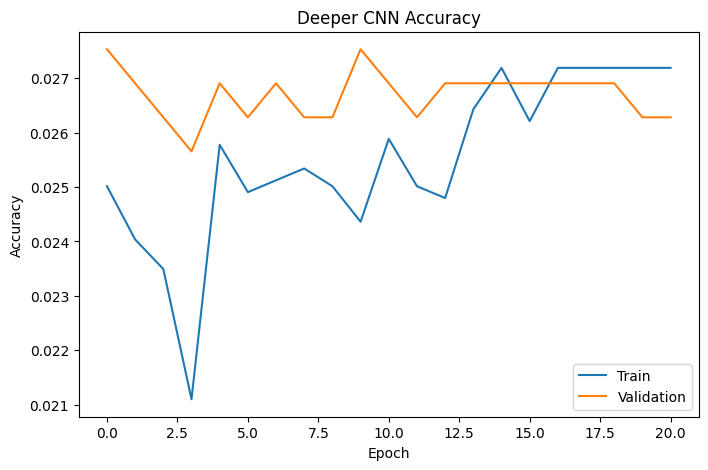

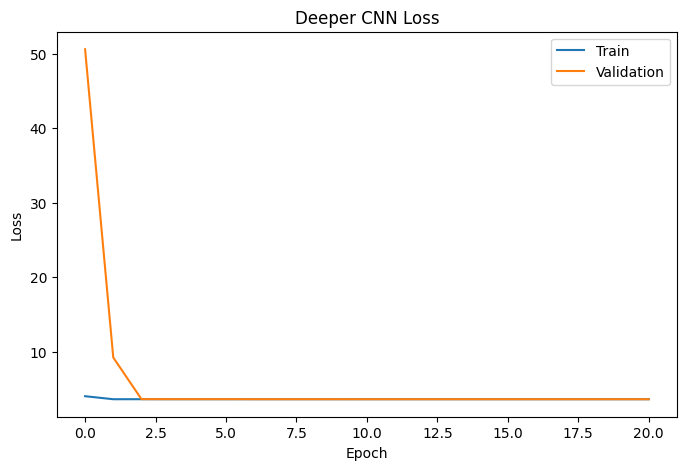

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step

 Deeper CNN
Accuracy : 0.02690863579474343

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        42
           1       0.00      0.00      0.00        43
           2       0.00      0.00      0.00        43
           3       0.00      0.00      0.00        42
           4       0.00      0.00      0.00        41
           5       0.00      0.00      0.00        41
           6       0.00      0.00      0.00        40
           7       0.00      0.00      0.00        43
           8       0.00      0.00      0.00        43
           9       0.00      0.00      0.00        42
          10       0.00      0.00      0.00        43
          11       0.00      0.00      0.00        43
          12       0.00      0.00      0.00        43
          13       0.00      0.00      0.00        42
          14       0.00      0.00      0.00        42
          15       0.03   

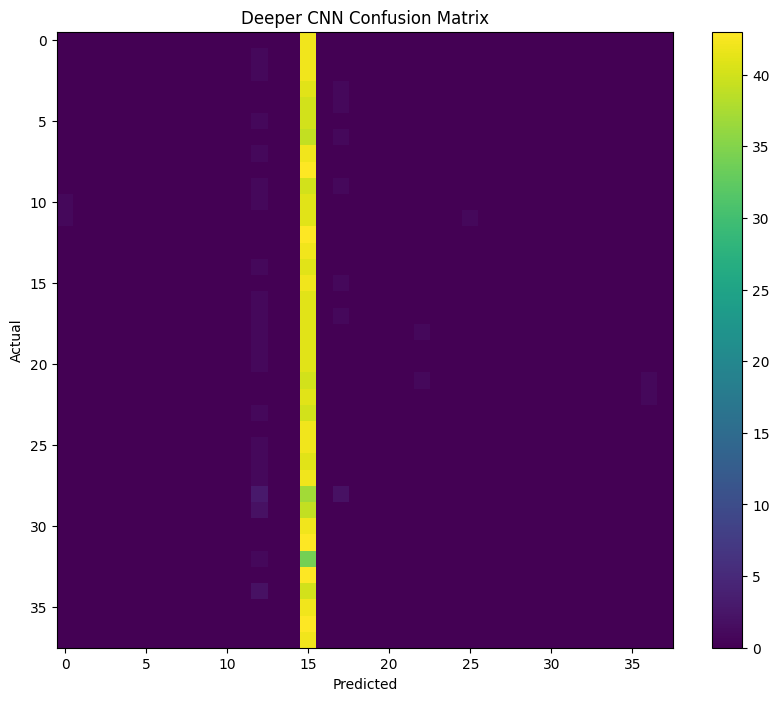

In [101]:
plot_graphs(history_deeper, "Deeper CNN")

deeper_results = evaluate_model(

    deeper_model,

    val_generator,

    "Deeper CNN"
)

#17. Build CNN with SGD Optimizer

In [76]:
sgd_model = create_deep_model(NUM_CLASSES)

sgd_model.compile(

    optimizer=SGD(learning_rate=0.01),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

#18. Train and Evaluate SGD Model

Training CNN with SGD...
Epoch 1/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 176ms/step - accuracy: 0.1923 - loss: 2.7984 - val_accuracy: 0.2522 - val_loss: 2.5514 - learning_rate: 0.0030
Epoch 2/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 167ms/step - accuracy: 0.1912 - loss: 2.7606 - val_accuracy: 0.2547 - val_loss: 2.6124 - learning_rate: 0.0030
Epoch 3/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 172ms/step - accuracy: 0.1995 - loss: 2.7468 - val_accuracy: 0.2710 - val_loss: 2.5898 - learning_rate: 0.0030
Epoch 4/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 49s 169ms/step - accuracy: 0.2012 - loss: 2.7362 - val_accuracy: 0.2785 - val_loss: 2.5263 - learning_rate: 0.0030
Epoch 5/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 177ms/step - accuracy: 0.2003 - loss: 2.7085 - val_accuracy: 0.2972 - val_loss: 2.4367 - learning_rate: 0.0030
Epoch 6/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 49s 171ms/step - accuracy: 0.2020 - loss: 2.7003 - val_accuracy: 0.2691 - val_loss: 2.5772 - learning_rate: 0.0030
Epoch 7/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 1

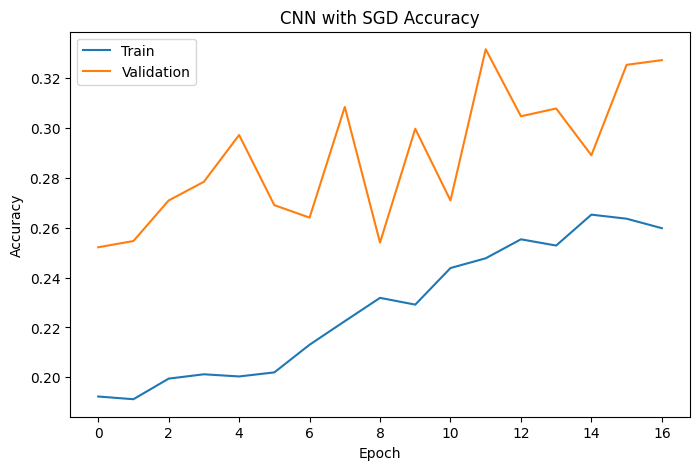

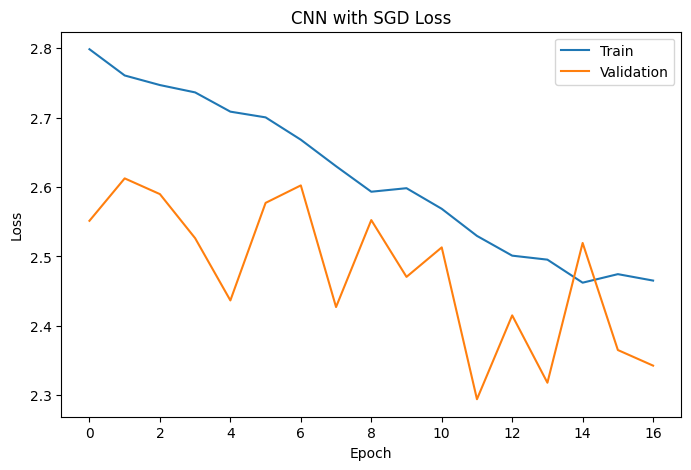

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step

 CNN with SGD
Accuracy : 0.3316645807259074

Classification Report:

              precision    recall  f1-score   support

           0       0.15      0.33      0.20        42
           1       0.76      0.30      0.43        43
           2       0.38      0.23      0.29        43
           3       0.31      0.43      0.36        42
           4       0.20      0.10      0.13        41
           5       0.14      0.34      0.20        41
           6       0.15      0.07      0.10        40
           7       0.12      0.02      0.04        43
           8       0.32      0.35      0.33        43
           9       0.53      0.62      0.57        42
          10       0.21      0.33      0.26        43
          11       0.46      0.14      0.21        43
          12       0.48      0.33      0.39        43
          13       0.27      0.29      0.28        42
          14       0.29      0.76      0.42        42
          15       0.33  

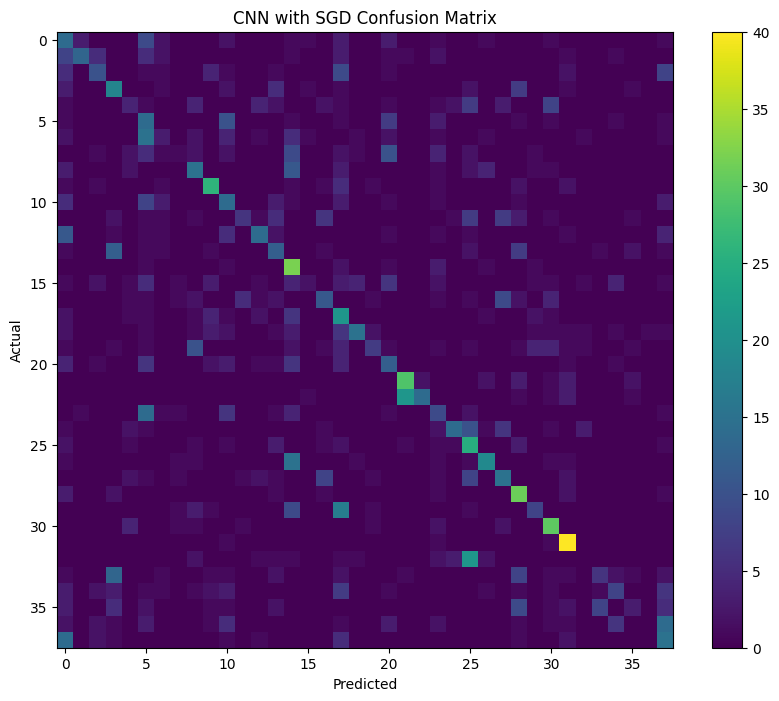

In [102]:
print("Training CNN with SGD...")

start_time = time.time()
history_sgd = sgd_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=DEEP_MODEL_EPOCHS,

    callbacks=get_callbacks()
)
end_time = time.time()
sgd_time = end_time - start_time

plot_graphs(history_sgd, "CNN with SGD")

sgd_results = evaluate_model(

    sgd_model,

    val_generator,

    "CNN with SGD"
)

#19. Build Ablation Model

In [78]:
def create_ablation_model(num_classes):

    model = Sequential([

        Conv2D(32, (3,3),
               activation="relu",
               padding="same",
               input_shape=(128,128,3)),

        BatchNormalization(),

        MaxPooling2D(2,2),


        Conv2D(64, (3,3),
               activation="relu",
               padding="same"),

        BatchNormalization(),

        MaxPooling2D(2,2),


        Flatten(),


        Dense(256, activation="relu"),

        Dense(num_classes,
              activation="softmax")
    ])

    model.compile(

        optimizer=Adam(0.001),

        loss="categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model


ablation_model = create_ablation_model(NUM_CLASSES)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#20. Train Ablation Model

In [103]:
print("Training Ablation Model...")

start_time = time.time()
history_ablation = ablation_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=DEEP_MODEL_EPOCHS,

    callbacks=get_callbacks()
)
end_time = time.time()
ablation_time = end_time - start_time

ablation_model.save(
    "/content/drive/MyDrive/ablation_model.keras"
)

Training Ablation Model...
Epoch 1/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 168ms/step - accuracy: 0.0921 - loss: 3.3508 - val_accuracy: 0.0839 - val_loss: 3.4945 - learning_rate: 2.7000e-05
Epoch 2/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 47s 163ms/step - accuracy: 0.0909 - loss: 3.3476 - val_accuracy: 0.0870 - val_loss: 3.4989 - learning_rate: 2.7000e-05
Epoch 3/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 47s 163ms/step - accuracy: 0.0935 - loss: 3.3288 - val_accuracy: 0.0895 - val_loss: 3.4997 - learning_rate: 2.7000e-05
Epoch 4/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 47s 163ms/step - accuracy: 0.0946 - loss: 3.3240 - val_accuracy: 0.0857 - val_loss: 3.5056 - learning_rate: 2.7000e-05
Epoch 5/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 47s 164ms/step - accuracy: 0.0967 - loss: 3.3145 - val_accuracy: 0.0882 - val_loss: 3.5172 - learning_rate: 8.1000e-06
Epoch 6/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 49s 171ms/step - accuracy: 0.0947 - loss: 3.3113 - val_accuracy: 0.0901 - val_loss: 3.5125 - learning_rate: 8.1000e-06


#21. Evaluate Ablation Model

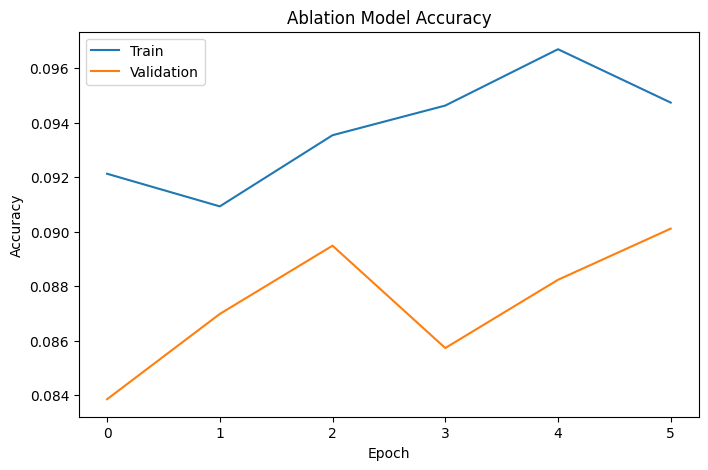

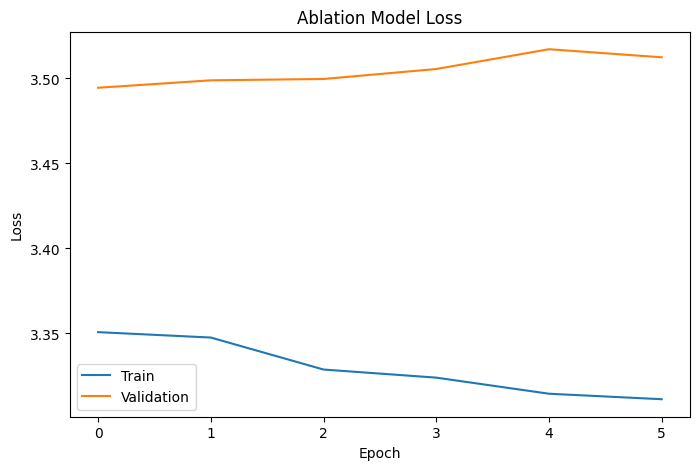

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step

 Ablation Model
Accuracy : 0.08385481852315395

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        42
           1       0.00      0.00      0.00        43
           2       0.00      0.00      0.00        43
           3       0.00      0.00      0.00        42
           4       0.00      0.00      0.00        41
           5       0.00      0.00      0.00        41
           6       0.00      0.00      0.00        40
           7       0.00      0.00      0.00        43
           8       0.03      0.84      0.06        43
           9       0.00      0.00      0.00        42
          10       0.00      0.00      0.00        43
          11       0.00      0.00      0.00        43
          12       0.00      0.00      0.00        43
          13       0.00      0.00      0.00        42
          14       0.00      0.00      0.00        42
          15       0.0

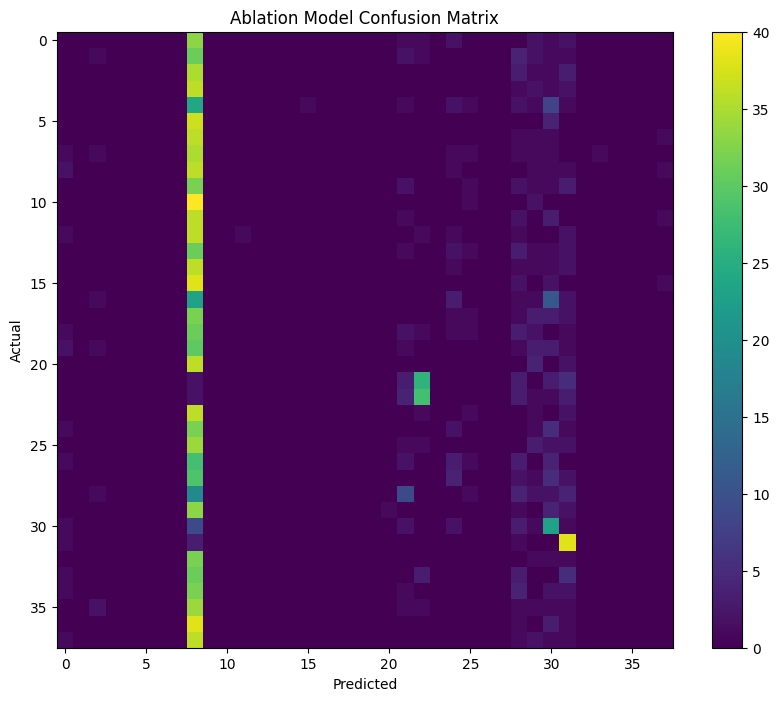

In [104]:
plot_graphs(history_ablation, "Ablation Model")

ablation_results = evaluate_model(

    ablation_model,

    val_generator,

    "Ablation Model"
)

#22. Create Transfer Learning Generators

In [81]:
transfer_train_generator = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=(128,128),

    batch_size=BATCH,

    class_mode="categorical",

    subset="training"
)

transfer_val_generator = val_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=(128,128),

    batch_size=BATCH,

    class_mode="categorical",

    subset="validation"
)

Found 9194 images belonging to 38 classes.
Found 1598 images belonging to 38 classes.


#23. Build MobileNetV2 Transfer Learning Model

In [82]:
base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(128,128,3)
)

base_model.trainable = False


transfer_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])


transfer_model.compile(

    optimizer=Adam(0.0005),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#24. Train Transfer Learning Model

In [105]:
print("Training MobileNetV2 Model...")

start_time = time.time()
history_transfer = transfer_model.fit(

    transfer_train_generator,

    validation_data=transfer_val_generator,

    epochs=TRANSFER_EPOCHS,

    callbacks=get_callbacks()
)
end_time = time.time()
transfer_time = end_time - start_time

Training MobileNetV2 Model...
Epoch 1/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 59s 203ms/step - accuracy: 0.8329 - loss: 0.5246 - val_accuracy: 0.8279 - val_loss: 0.5466 - learning_rate: 1.0000e-05
Epoch 2/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 185ms/step - accuracy: 0.8461 - loss: 0.4754 - val_accuracy: 0.8223 - val_loss: 0.5304 - learning_rate: 1.0000e-05
Epoch 3/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 181ms/step - accuracy: 0.8535 - loss: 0.4564 - val_accuracy: 0.8379 - val_loss: 0.5019 - learning_rate: 1.0000e-05
Epoch 4/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - accuracy: 0.8682 - loss: 0.4119 - val_accuracy: 0.8411 - val_loss: 0.4932 - learning_rate: 1.0000e-05
Epoch 5/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 182ms/step - accuracy: 0.8607 - loss: 0.4153 - val_accuracy: 0.8454 - val_loss: 0.4786 - learning_rate: 1.0000e-05
Epoch 6/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 82s 182ms/step - accuracy: 0.8715 - loss: 0.3941 - val_accuracy: 0.8598 - val_loss: 0.4593 - learning_rate: 1.0000e-05
Epoch 7/15
288/2

#25. Evaluate Transfer Learning Model

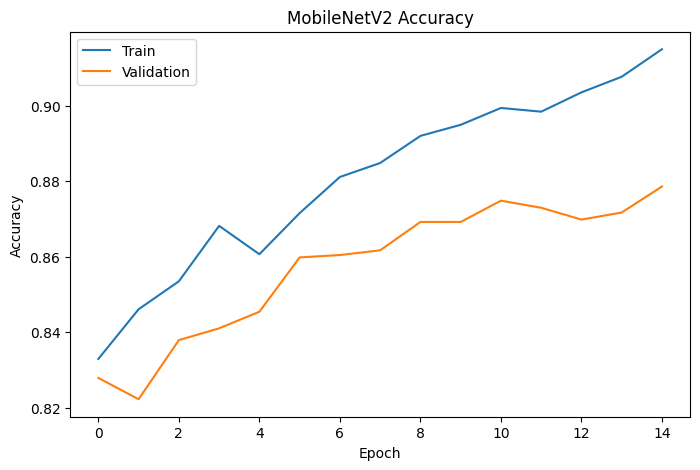

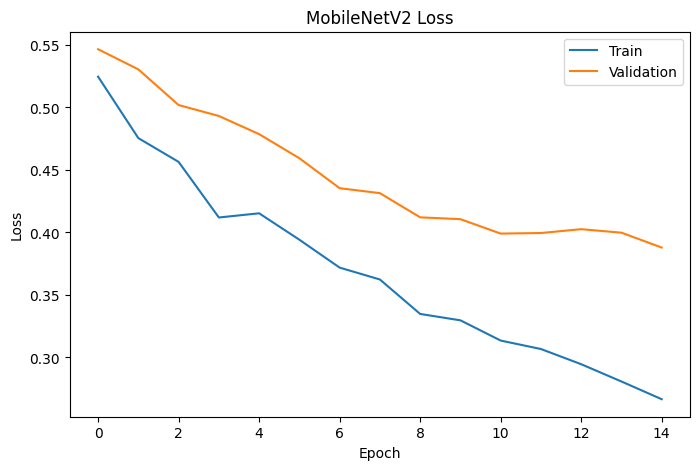

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step

 MobileNetV2
Accuracy : 0.8785982478097623

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.76      0.76        42
           1       0.90      0.84      0.87        43
           2       0.90      0.84      0.87        43
           3       0.95      1.00      0.98        42
           4       0.93      0.93      0.93        41
           5       0.72      0.88      0.79        41
           6       0.93      0.68      0.78        40
           7       0.87      0.79      0.83        43
           8       0.95      0.98      0.97        43
           9       0.91      0.98      0.94        42
          10       0.84      0.88      0.86        43
          11       0.89      0.79      0.84        43
          12       0.93      0.93      0.93        43
          13       0.93      0.98      0.95        42
          14       0.95      0.98      0.96        42
          15       0.76   

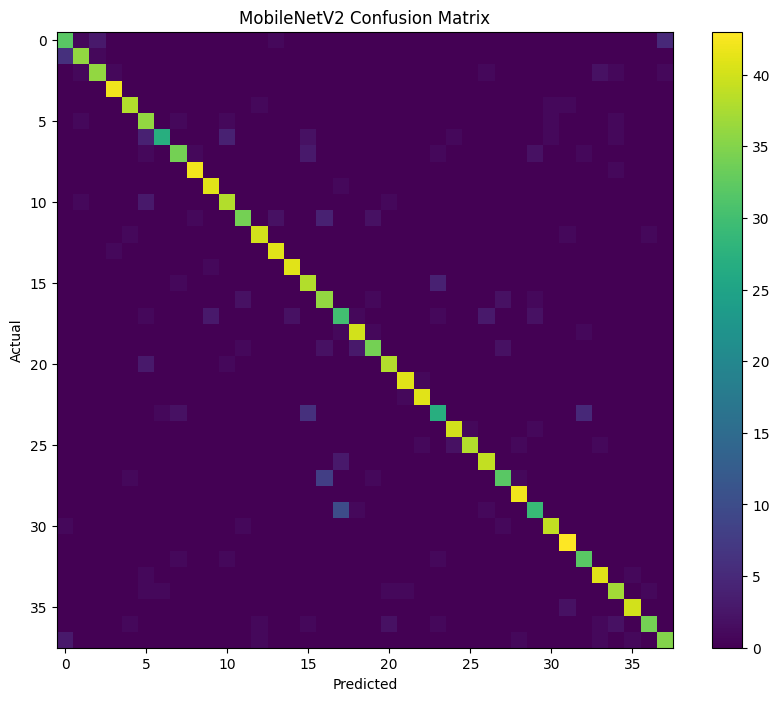

In [106]:
plot_graphs(history_transfer, "MobileNetV2")

transfer_results = evaluate_model(

    transfer_model,

    val_generator,

    "MobileNetV2"
)

#26. Fine Tune MobileNetV2

In [107]:
base_model.trainable = True

transfer_model.compile(

    optimizer=Adam(1e-5),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

start_time = time.time()
history_finetune = transfer_model.fit(

    transfer_train_generator,

    validation_data=transfer_val_generator,

    epochs=FINE_TUNE_EPOCHS,

    callbacks=get_callbacks()
)
end_time = time.time()
finetune_time = end_time - start_time

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 125s 276ms/step - accuracy: 0.9184 - loss: 0.2579 - val_accuracy: 0.8811 - val_loss: 0.3783 - learning_rate: 1.0000e-05
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.9205 - loss: 0.2454 - val_accuracy: 0.8767 - val_loss: 0.3781 - learning_rate: 1.0000e-05
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 176ms/step - accuracy: 0.9206 - loss: 0.2471 - val_accuracy: 0.8748 - val_loss: 0.3809 - learning_rate: 1.0000e-05
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.9213 - loss: 0.2389 - val_accuracy: 0.8805 - val_loss: 0.3743 - learning_rate: 1.0000e-05
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 183ms/step - accuracy: 0.9235 - loss: 0.2341 - val_accuracy: 0.8867 - val_loss: 0.3535 - learning_rate: 1.0000e-05
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 177ms/step - accuracy: 0.9251 - loss: 0.2219 - val_accuracy: 0.8930 - val_loss: 0.3448 - learning_rate: 1.0000e-05
Epoch 7/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 82s 1

#27. Evaluate Fine Tuned Model

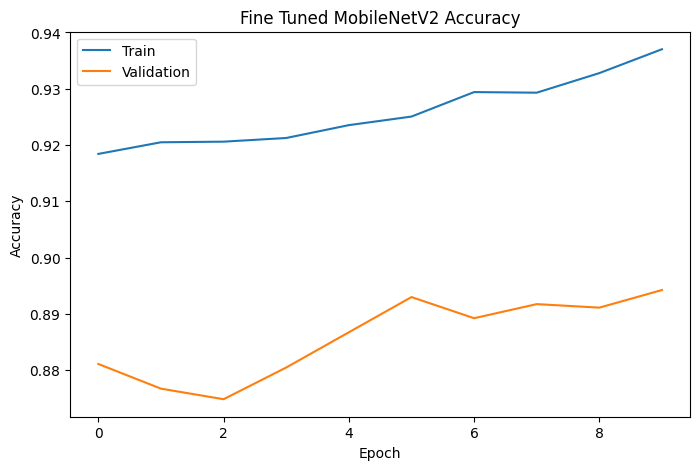

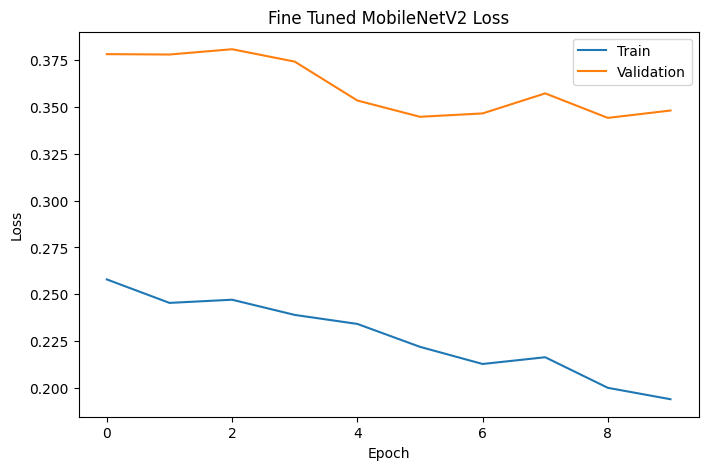

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step

 Fine Tuned MobileNetV2
Accuracy : 0.8911138923654568

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.81      0.82        42
           1       0.91      0.91      0.91        43
           2       0.93      0.88      0.90        43
           3       0.95      0.98      0.96        42
           4       0.93      0.90      0.91        41
           5       0.78      0.93      0.84        41
           6       0.93      0.68      0.78        40
           7       0.92      0.81      0.86        43
           8       0.93      1.00      0.97        43
           9       0.91      0.95      0.93        42
          10       0.82      0.86      0.84        43
          11       0.90      0.81      0.85        43
          12       0.98      0.93      0.95        43
          13       0.95      0.98      0.96        42
          14       0.91      0.93      0.92        42
          15 

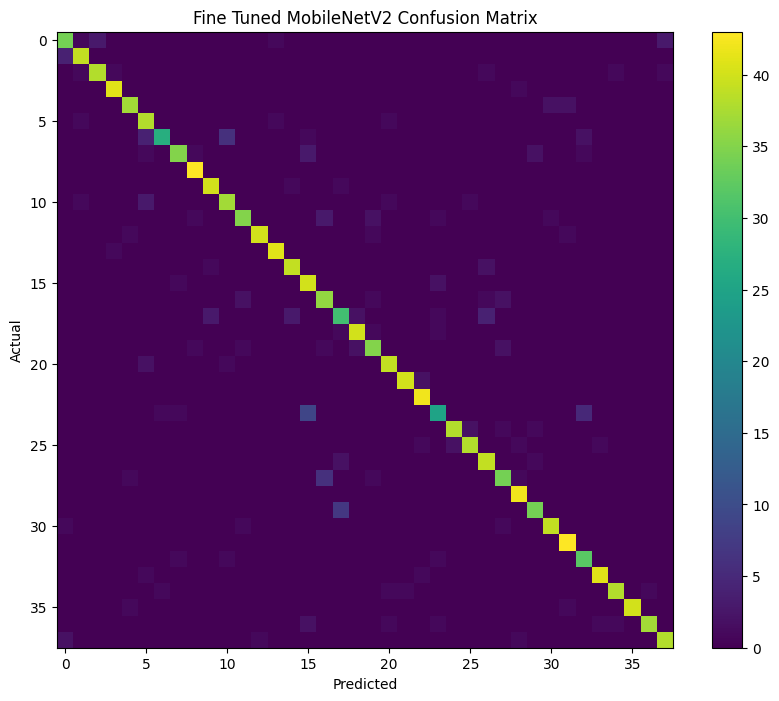

In [108]:
plot_graphs(history_finetune, "Fine Tuned MobileNetV2")

finetune_results = evaluate_model(

    transfer_model,

    val_generator,

    "Fine Tuned MobileNetV2"
)

#28. Compare All Models

,model,accuracy,precision,recall,f1_score
4,MobileNetV2,0.891114,0.893620,0.891114,0.890241
5,Fine Tuned MobileNetV2,0.891114,0.893620,0.891114,0.890241
0,Baseline CNN,0.695244,0.705708,0.695244,0.693923
2,CNN with SGD,0.331665,0.359609,0.331665,0.309837
3,Ablation Model,0.083855,0.034895,0.083855,0.044193
1,Deeper CNN,0.026909,0.004089,0.026909,0.002466


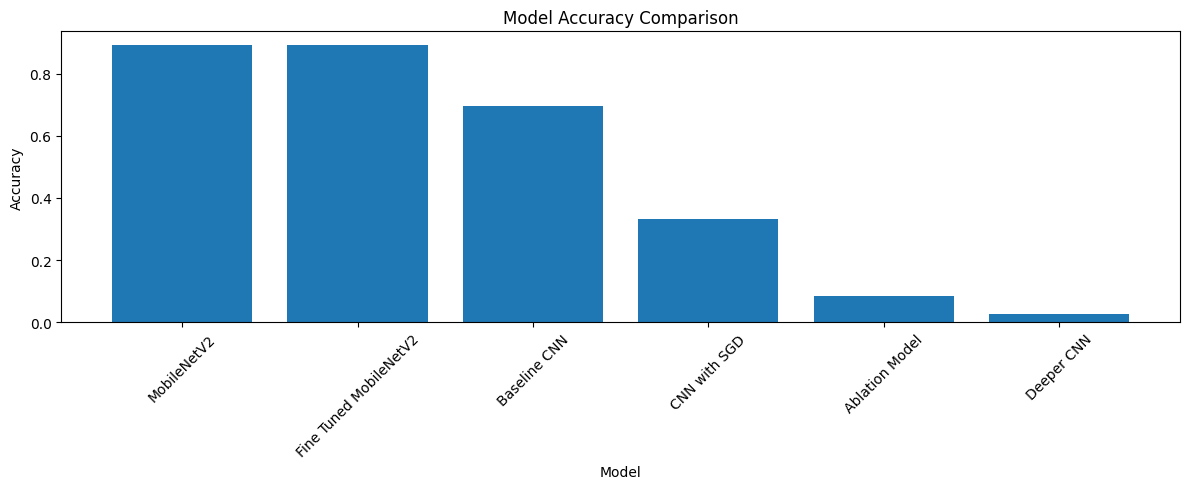

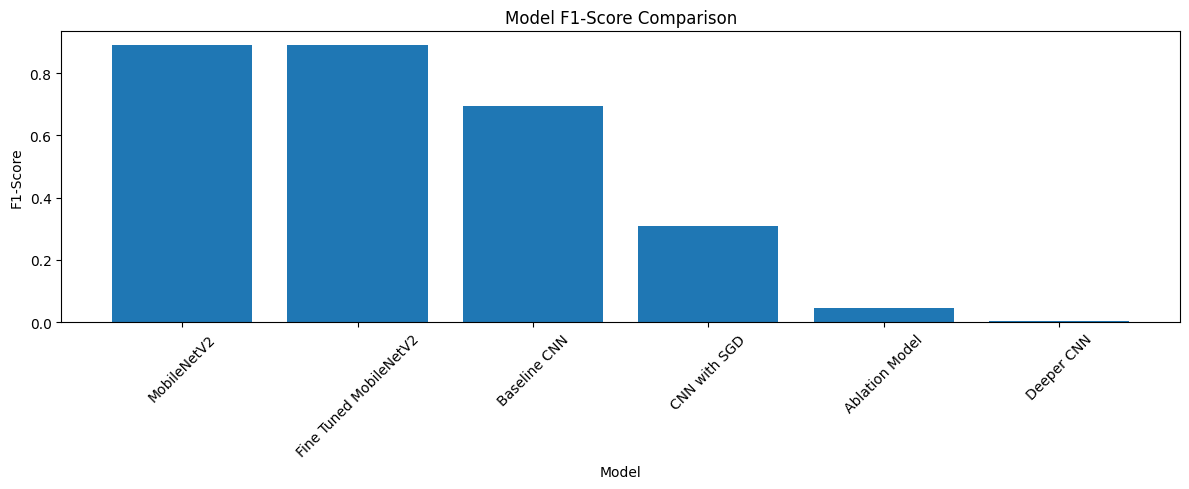

In [117]:
# ============================================
# STORE RESULTS
# ============================================

results = [

    baseline_results,

    deeper_results,

    sgd_results,

    ablation_results,

    transfer_results,

    finetune_results
]


# ============================================
# CREATE DATAFRAME
# ============================================

results_df = pd.DataFrame(results)


# ============================================
# SORT RESULTS
# ============================================

results_df = results_df.sort_values(
    by="accuracy",
    ascending=False
)


# ============================================
# SHOW RESULTS TABLE
# ============================================

display(results_df)


# ============================================
# ACCURACY GRAPH
# ============================================

plt.figure(figsize=(12,5))

plt.bar(
    results_df["model"],
    results_df["accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Model")

plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# ============================================
# F1 SCORE GRAPH
# ============================================

plt.figure(figsize=(12,5))

plt.bar(
    results_df["model"],
    results_df["f1_score"]
)

plt.title("Model F1-Score Comparison")

plt.xlabel("Model")

plt.ylabel("F1-Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

#29. Predict Sample Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


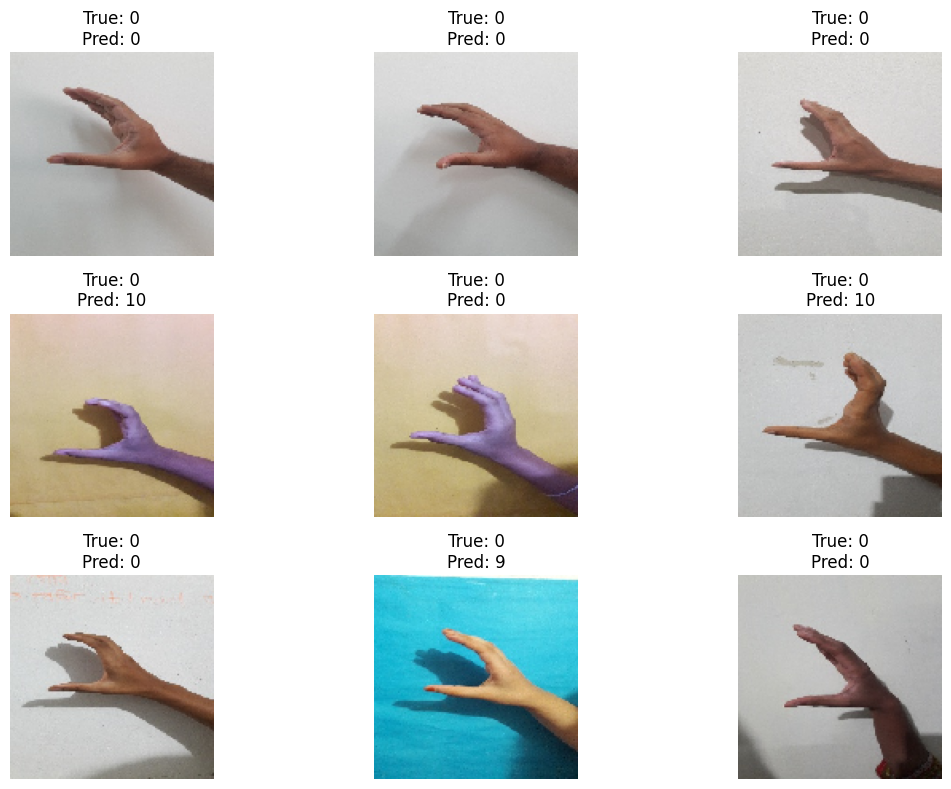

In [118]:
images, labels = next(val_generator)

predictions = transfer_model.predict(images)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(labels, axis=1)


plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(
        f"True: {idx_to_class[true_classes[i]]}\n"
        f"Pred: {idx_to_class[predicted_classes[i]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()